### Normal random forest

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
df = pd.read_csv(r"C:\Users\MANMOHAN\OneDrive\Desktop\codes\Datasets\randomm\heart_disease_uci.csv")

print("Dataset Shape")
print(df.shape)

print("\nFirst 5 Rows")
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Shape
(920, 11)

First 5 Rows
   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak  num  
0   150.0  False      2.3    0  
1   108.0   True      1.5    2  
2   129.0   True      2.6    1  
3   187.0  False      3.5    0  
4   172.0  False      1.4    0  

Missing Values
age          0
sex          0
cp           0
trestbps    59
chol        30
fbs         90
restecg      2
thalch      55
exang       55
oldpeak     62
num          0
dtype: int64


In [6]:
# Numeric fill with median
numeric_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical fill with mode
categorical_cols = ['fbs', 'exang', 'restecg']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning")
print(df.isnull().sum())


Missing Values After Cleaning
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64


C:\Users\MANMOHAN\AppData\Local\Temp\ipykernel_15672\1393632242.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [7]:
# 0 = No Disease, 1 = Disease
df['target'] = (df['num'] > 0).astype(int)
df.drop(columns=['num'], inplace=True)

print("\nTarget Distribution")
print(df['target'].value_counts())


Target Distribution
target
1    509
0    411
Name: count, dtype: int64


In [8]:
le = LabelEncoder()

#Male/Female = 0/1
df['sex'] = le.fit_transform(df['sex'])

df['cp'] = le.fit_transform(df['cp'])

df['restecg'] = le.fit_transform(df['restecg'])

#True/False = 1/0
df['fbs'] = df['fbs'].map({True: 1, False: 0, 1: 1, 0: 0}).astype(int)
df['exang'] = df['exang'].map({True: 1, False: 0, 1: 1, 0: 0}).astype(int)

print("\nData After Encoding")
print(df.head())


Data After Encoding
   age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  target
0   63    1   3     145.0  233.0    1        0   150.0      0      2.3       0
1   67    1   0     160.0  286.0    0        0   108.0      1      1.5       1
2   67    1   0     120.0  229.0    0        0   129.0      1      2.6       1
3   37    1   2     130.0  250.0    0        1   187.0      0      3.5       0
4   41    0   1     130.0  204.0    0        0   172.0      0      1.4       0


In [9]:
X = df.drop(columns=['target'])
y = df['target']

# 80 20
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

print("\nTrain/Test Split")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Train/Test Split
Training samples : 736
Testing  samples : 184


In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [11]:
print("RANDOM FOREST RESULTS")
print(f"Accuracy : {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['No Disease', 'Disease']))

RANDOM FOREST RESULTS
Accuracy : 83.15%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.80      0.79        75
     Disease       0.86      0.85      0.86       109

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [15]:
import joblib

joblib.dump(rf_model, r'C:\Users\MANMOHAN\OneDrive\Desktop\codes\AI or ML\MLops\random_forest_heart_disease.pkl')

['C:\\Users\\MANMOHAN\\OneDrive\\Desktop\\codes\\AI or ML\\MLops\\random_forest_heart_disease.pkl']

### Grid search

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# --- Define hyperparameter grid ---
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# --- Run Grid Search with 5-fold cross validation ---
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# --- Best parameters & accuracy ---
print("Best Parameters :", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_ * 100, 2), "%")

# --- Evaluate best model on test set ---
best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)

print("\nTest Accuracy:", round(accuracy_score(y_test, best_preds) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Disease']))



Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters : {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy: 81.39 %

Test Accuracy: 82.61 %

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.81      0.79        75
     Disease       0.87      0.83      0.85       109

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



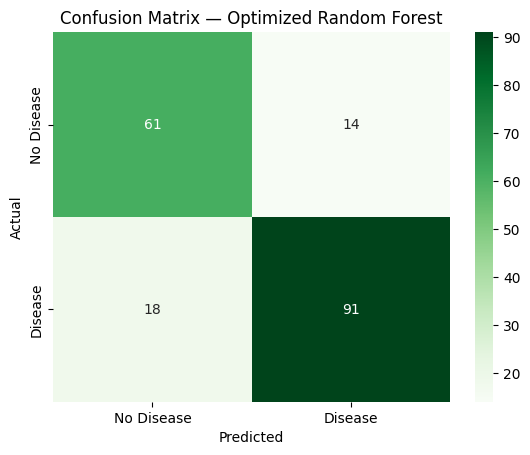

In [13]:
# --- Confusion Matrix ---

cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Optimized Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [14]:
# --- Save best model ---
joblib.dump(best_model, r'C:\Users\MANMOHAN\OneDrive\Desktop\codes\AI or ML\MLops\random_forest_most_optimized.pkl')

['C:\\Users\\MANMOHAN\\OneDrive\\Desktop\\codes\\AI or ML\\MLops\\random_forest_most_optimized.pkl']

In [16]:
# --- Load and verify ---
loaded_model = joblib.load(r'C:\Users\MANMOHAN\OneDrive\Desktop\codes\AI or ML\MLops\random_forest_most_optimized.pkl')
verify_preds = loaded_model.predict(X_test)
print("✅ Model loaded and verified! Accuracy:", round(accuracy_score(y_test, verify_preds) * 100, 2), "%")

✅ Model loaded and verified! Accuracy: 82.61 %
